In [1]:
import pandas as pd
import numpy as np
import pickle
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
with open('data/processed/X_train.pkl', 'rb') as f:
    X_train = pickle.load(f)

with open('data/processed/X_test.pkl', 'rb') as f:
    X_test = pickle.load(f)

with open('data/processed/y_train.pkl', 'rb') as f:
    y_train = pickle.load(f)

with open('data/processed/y_test.pkl', 'rb') as f:
    y_test = pickle.load(f)

print("Training set:", X_train.shape)
print("Test set:", X_test.shape)

Training set: (564, 56)
Test set: (96, 56)


In [4]:
model = RandomForestClassifier(n_estimators=100, random_state=42, max_depth=10)
model.fit(X_train, y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,10
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [5]:
y_pred = model.predict(X_test)
y_pred_proba = model.predict_proba(X_test)[:, 1]

In [ ]:
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_pred_proba)

print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1 Score:", f1)
print("ROC-AUC:", roc_auc)

Random Forest Results:
Accuracy: 0.9583333333333334
Precision: 0.8888888888888888
Recall: 0.96
F1 Score: 0.9230769230769231
ROC-AUC: 0.9864788732394366


In [7]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.99      0.96      0.97        71
           1       0.89      0.96      0.92        25

    accuracy                           0.96        96
   macro avg       0.94      0.96      0.95        96
weighted avg       0.96      0.96      0.96        96



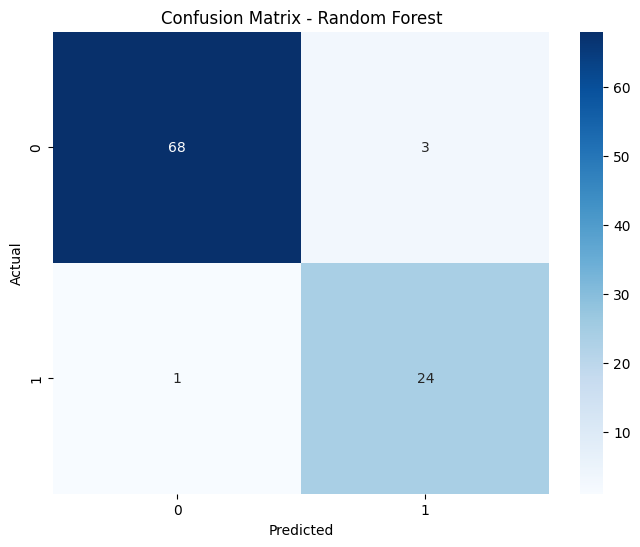

In [8]:
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix - Random Forest')
plt.show()

In [9]:
feature_importance = pd.DataFrame({
    'feature': X_train.columns,
    'importance': model.feature_importances_
}).sort_values('importance', ascending=False)

feature_importance.head(10)

,feature,importance
1,VisITedResources,0.177486
4,engagement_score,0.163684
0,raisedhands,0.119745
5,is_absent_frequently,0.112189
2,AnnouncementsView,0.092916
6,parent_engaged,0.063549
7,parent_satisfied,0.049639
3,Discussion,0.043412
54,Relation_Father,0.019443
10,GradeID_encoded,0.015724


In [10]:
with open('models/random_forest.pkl', 'wb') as f:
    pickle.dump(model, f)